<a href="https://colab.research.google.com/github/JoshuaMawutor/Deep-Learning/blob/main/Hyperparameters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 11.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import os
import argparse
import keras
import tensorflow as tf
from keras.models import Sequential, load_model, Model
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization,Rescaling, Activation
from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from keras.utils import image_dataset_from_directory,img_to_array, array_to_img, save_img
from sklearn.metrics import classification_report, confusion_matrix
from keras_tuner import RandomSearch, Hyperband, HyperParameters



In [3]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
! nvidia-smi

Fri May 15 20:13:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
def get_data(path):
    image_data_list = []
    label = []
    for i in os.listdir(path):
        if i.endswith('jpg') or i.endswith('png'):
            elements = os.path.join(path, i)
            img = cv2.imread(elements)
            img = cv2.resize(img, (img_size, img_size))
            image_data_list.append(img)
            if i.startswith('dog'):
                lab = 1
            else:
                lab = 0
            label.append(lab)
    label = np.array(label)
    image_data_list = np.array(image_data_list)
    plt.imshow(image_data_list[50])
    plt.show()
    image = image_data_list.shape[0]
    print(image)
    return image_data_list, label

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
data_augmentation = Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
])

In [8]:
def buildmodel(hp):
    model = keras.Sequential()
    model.add(Rescaling(1./255, input_shape=(128, 128, 3)))
    model.add(data_augmentation)

    conv2d_layers = hp.Int("Conv2d", 1, 4, step=1)

    for i in range(conv2d_layers):
        filter = hp.Choice(f"filters{i}", values=[32, 64, 128, 256])
        kernel = hp.Choice(f"conv_kernel{i}", [3, 5])
        act1 = hp.Choice(f"C_activation{i}", ["relu", "tanh"])
        model.add(Conv2D(filters=filter, kernel_size=kernel, activation=act1))
        model.add(MaxPooling2D(pool_size=(2, 2), name=f'max_pooling_{i}'))

    model.add(Flatten())

    dense_layers = hp.Int("units", 1, 6, step=1)
    use_dropout = hp.Boolean("use_dropout")
    use_l2 = hp.Boolean("use_l2")

    for j in range(dense_layers):
        unit = hp.Choice(f"dense_units{j}", values=[64, 128, 256, 512])
        act2 = hp.Choice(f"d_activation{j}", ["relu", "tanh"])

        if use_l2:
            l2 = hp.Float("regularizer", 1e-5, 1e-2, sampling="log")
            model.add(Dense(units=unit, activation=act2, kernel_regularizer=keras.regularizers.L2(l2)))
        else:
            model.add(Dense(units=unit, activation=act2))

        if use_dropout:
            dropout_rate = hp.Float("dropout_rate", 0.2, 0.5, step=0.1)
            model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation="sigmoid"))

    learning_rate = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [9]:
buildmodel(HyperParameters())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


<Sequential name=sequential_1, built=True>

In [10]:
tuner = Hyperband(buildmodel,
                     objective='val_accuracy',
                     max_epochs=10,
                     factor=3,
                     directory='my_dir',
                     project_name='intro_to_kt')

In [11]:
tuner.search_space_summary()

Search space summary
Default search space size: 10
Conv2d (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
filters0 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128, 256], 'ordered': True}
conv_kernel0 (Choice)
{'default': 3, 'conditions': [], 'values': [3, 5], 'ordered': True}
C_activation0 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh'], 'ordered': False}
units (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 6, 'step': 1, 'sampling': 'linear'}
use_dropout (Boolean)
{'default': False, 'conditions': []}
use_l2 (Boolean)
{'default': False, 'conditions': []}
dense_units0 (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256, 512], 'ordered': True}
d_activation0 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh'], 'ordered': False}
lr (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None,

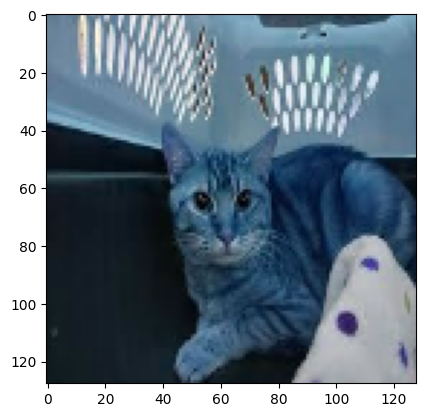

557


In [12]:
import cv2
img_size = 128
path = "/content/drive/MyDrive/Colab Notebooks/Train"
image_data_list, label = get_data(path)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(image_data_list, label, test_size=0.2, random_state=42)


In [14]:
print(tf.test.gpu_device_name())

/device:GPU:0


In [15]:
! nvidia-smi

Fri May 15 20:14:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P0             29W /   70W |     237MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:
tuner.search(X_train, y_train, epochs=10, validation_split=0.2)

Trial 30 Complete [00h 00m 24s]
val_accuracy: 0.5730336904525757

Best val_accuracy So Far: 0.617977499961853
Total elapsed time: 00h 05m 08s


In [17]:
best_model = tuner.get_best_models(num_models=1)[0]
print(best_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 124, 124, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_0 (MaxPooling2D)    │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_1 (MaxPooling2D)    │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     7,373,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,417,889 (28.30 MB)

 Trainable params: 7,417,889 (28.30 MB)

 Non-trainable params: 0 (0.00 B)

None


In [18]:
best_params = tuner.get_best_hyperparameters(3)
print(best_params[0].values)
print(best_params[1].values)

{'Conv2d': 2, 'filters0': 32, 'conv_kernel0': 5, 'C_activation0': 'relu', 'units': 6, 'use_dropout': True, 'use_l2': False, 'dense_units0': 256, 'd_activation0': 'relu', 'lr': 0.0007256000814102282, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 2, 'tuner/round': 0, 'filters1': 32, 'conv_kernel1': 3, 'C_activation1': 'relu', 'dropout_rate': 0.2, 'dense_units1': 64, 'd_activation1': 'relu', 'dense_units2': 64, 'd_activation2': 'relu', 'dense_units3': 64, 'd_activation3': 'relu', 'dense_units4': 64, 'd_activation4': 'relu', 'dense_units5': 64, 'd_activation5': 'relu'}
{'Conv2d': 1, 'filters0': 64, 'conv_kernel0': 5, 'C_activation0': 'relu', 'units': 3, 'use_dropout': False, 'use_l2': True, 'dense_units0': 64, 'd_activation0': 'relu', 'lr': 0.000665448233667236, 'filters1': 32, 'conv_kernel1': 5, 'C_activation1': 'tanh', 'dropout_rate': 0.4, 'dense_units1': 64, 'd_activation1': 'relu', 'dense_units2': 64, 'd_activation2': 'tanh', 'dense_units3': 128, 'd_activation3': 'relu'

### All parameters

In [19]:
def buildmodel(hp):
    model = keras.Sequential()
    model.add(Rescaling(1./255, input_shape=(128, 128, 3)))
    model.add(data_augmentation)

    conv2d_layers = hp.Int("Conv2d", 1, 4, step=1)

    for i in range(conv2d_layers):
        filter = hp.Choice(f"filters{i}", values=[32, 64, 128, 256])
        kernel = hp.Choice(f"conv_kernel{i}", [3, 5])
        act1 = hp.Choice(f"C_activation{i}", ["relu", "tanh"])
        model.add(Conv2D(filters=filter, kernel_size=kernel, activation=act1))
        model.add(MaxPooling2D(pool_size=(2, 2), name=f'max_pooling_{i}'))

    model.add(Flatten())

    dense_layers = hp.Int("units", 1, 6, step=1)
    use_dropout = hp.Boolean("use_dropout")
    use_l2 = hp.Boolean("use_l2")

    for j in range(dense_layers):
        unit = hp.Choice(f"dense_units{j}", values=[64, 128, 256])
        act2 = hp.Choice(f"d_activation{j}", ["relu", "tanh"])

        if use_l2:
            l2 = hp.Float("regularizer", 1e-5, 1e-2, sampling="log")
            model.add(Dense(units=unit, activation=act2, kernel_regularizer=keras.regularizers.L2(l2)))
        else:
            model.add(Dense(units=unit, activation=act2))

        if use_dropout:
            dropout_rate = hp.Float("dropout_rate", 0.2, 0.5, step=0.1)
            model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation="sigmoid"))

    learning_rate = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [ ]:
import cv2
img_size = 128
path = "/content/drive/MyDrive/Colab Notebooks/cat_dog"
image_data_list, label = get_data(path)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(image_data_list, label, test_size=0.2, random_state=42)

In [ ]:
tuner = Hyperband(buildmodel,
                     objective='val_accuracy',
                     max_epochs=10,
                     factor=3,
                     directory='all_dir',
                     project_name='intro_dir')

In [ ]:
total = len(X_train)
val_size = int(total * 0.2)

val_dataset = tf.data.Dataset.from_tensor_slices((X_train[:val_size], y_train[:val_size]))
train_dataset = tf.data.Dataset.from_tensor_slices((X_train[val_size:], y_train[val_size:]))

val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

tuner.search(train_dataset, epochs=10, validation_data=val_dataset)